# Updated KLPT Preprocessing Analysis And Comparison
Measures how much of the KurdiSent corpus KLPT can analyse, and how that coverage improves once we **wave through** non-word tokens (punctuation, emojis, Latin), and apply the **schwa whitelist** (`ه→ە`) to rescue high-frequency function words like له / به.

**Definitions**
* *Word token* = contains at least one Arabic-script letter. Punctuation / Latin / emoji are non-words.
* Proper nouns (e.g. کەرکوک) stay in *Genuine OOV* — KLPT honestly does not cover them. We do not inflate coverage by hiding them.

In [1]:
!pip install klpt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 651.7/651.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.6/930.6 kB 19.2 MB/s eta 0:00:00


## Setup

In [2]:
import re
import pandas as pd
from functools import lru_cache
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from google.colab import drive

from klpt.preprocess import Preprocess
from klpt.tokenize import Tokenize
from klpt.stem import Stem

klpt_preprocessor = Preprocess("Sorani", "Arabic")
klpt_tokenizer    = Tokenize("Sorani", "Arabic")
klpt_stemmer      = Stem("Sorani", "Arabic")

In [3]:
drive.mount("/content/drive")
DIR_PATH       = "/content/drive/MyDrive/google_colab/kusa"
DATA_PATH      = DIR_PATH + "/datasets"
KURDISENT_PATH = DATA_PATH + "/KurdiSent.csv"
FIG_PATH       = DIR_PATH + "/klpt_coverage_before_after.png"

df_ckb = pd.read_csv(KURDISENT_PATH)
print(f"Loaded {len(df_ckb)} rows")

Mounted at /content/drive
Loaded 12306 rows


## Coverage logic

In [4]:
# First Improvment!
SCHWA_FIXES = {"له":"لە", "به":"بە", "که":"کە", "نه":"نە", "وه":"وە"}

MWE_SEP    = "\u2012"
WORD_BOUND = "\u2581"
KURDISH_RE = re.compile(r"[\u0600-\u06FF\u0750-\u077F]")  # has an Arabic-script letter?

def is_word(tok):
    return bool(KURDISH_RE.search(tok))

@lru_cache(maxsize=None)
def analyze_ok(tok):
    try:
        return bool(klpt_stemmer.analyze(tok))
    except Exception:
        return False

def get_subtokens(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"[\u0617-\u061A\u064B-\u0652]", "", text)
    surface = klpt_preprocessor.preprocess(text).strip()
    subs = []
    for w in klpt_tokenizer.word_tokenize(surface):
        w = w.replace(WORD_BOUND, "")
        for part in w.split(MWE_SEP):
            part = part.strip()
            if part:
                subs.append(part)
    return subs

def count_text(text):
    c = Counter()
    for tok in get_subtokens(str(text)):
        word = is_word(tok)
        c["word_tokens" if word else "nonword_tokens"] += 1

        # base logic
        if analyze_ok(tok):
            c["before_recognized"] += 1
        else:
            c["before_unrecognized"] += 1

        # wave trough + whitelist
        if not word:
            c["after_waved"] += 1                    # correctly passed through
        else:
            fixed = SCHWA_FIXES.get(tok, tok)
            if analyze_ok(fixed):
                if fixed != tok:
                    c["after_recovered"] += 1        # rescued by whitelist
                else:
                    c["after_recognized"] += 1       # already recognised
            else:
                c["after_oov"] += 1                  # genuine remaining gap
    return c

## Run over the full dataset

In [5]:
tqdm.pandas(desc="Analysing coverage")
counts = Counter()
for c in df_ckb["text"].progress_apply(count_text):
    counts.update(c)

word_tokens = counts["word_tokens"]
total       = counts["word_tokens"] + counts["nonword_tokens"]

cov_original   = counts["before_recognized"] / total
cov_durchwink  = counts["before_recognized"] / word_tokens
cov_whitelist  = (counts["before_recognized"] + counts["after_recovered"]) / word_tokens

print(f"Tokens total .......... {total:,}")
print(f"  words ............... {word_tokens:,}")
print(f"  non-words (waved) ... {counts['nonword_tokens']:,}")
print(f"Recovered by whitelist . {counts['after_recovered']:,}")
print(f"Remaining OOV (after) .. {counts['after_oov']:,}")
print()
print(f"Coverage | original (all tokens)   : {cov_original:6.1%}")
print(f"Coverage | + wave trough (words)   : {cov_durchwink:6.1%}")
print(f"Coverage | + whitelist             : {cov_whitelist:6.1%}")

Analysing coverage:   0%|          | 0/12306 [00:00<?, ?it/s]

Tokens total .......... 129,053
  words ............... 112,805
  non-words (waved) ... 16,248
Recovered by whitelist . 3,440
Remaining OOV (after) .. 36,502

Coverage | original (all tokens)   :  56.5%
Coverage | + wave trough (words)   :  64.6%
Coverage | + whitelist             :  67.6%


## Before / After figure

Saved figure to: /content/drive/MyDrive/google_colab/kusa/klpt_coverage_before_after.png


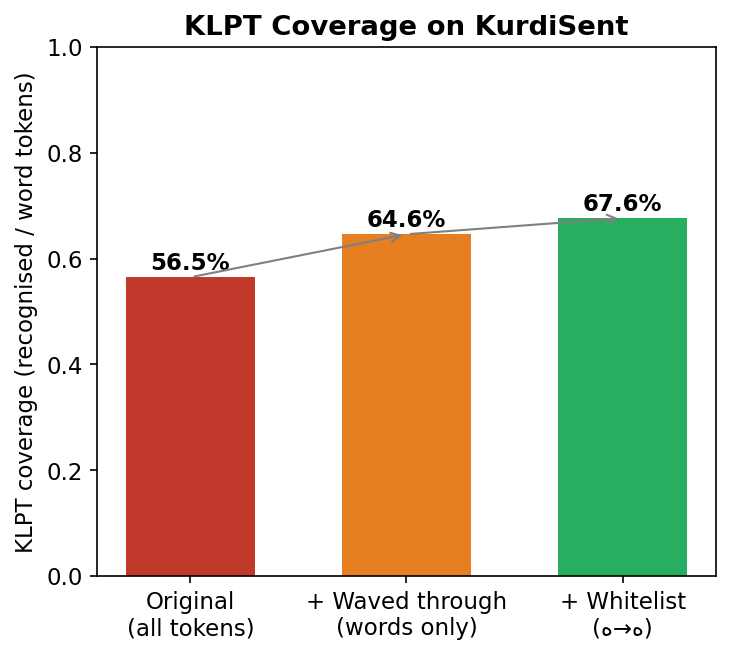

In [6]:
plt.rcParams.update({"figure.dpi": 150, "font.size": 11})
fig, ax = plt.subplots(figsize=(5, 4.5))

levels = ["Original\n(all tokens)", "+ Waved through\n(words only)", "+ Whitelist\n(ه→ە)"]
vals   = [cov_original, cov_durchwink, cov_whitelist]
colors = ["#c0392b", "#e67e22", "#27ae60"]

bars = ax.bar(levels, vals, color=colors, width=0.6)
ax.set_ylim(0, 1)
ax.set_ylabel("KLPT coverage (recognised / word tokens)")
ax.set_title("KLPT Coverage on KurdiSent", fontweight="bold")

for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.1%}",
            ha="center", fontweight="bold")

ax.annotate("", xy=(1, cov_durchwink), xytext=(0, cov_original),
            arrowprops=dict(arrowstyle="->", color="grey"))
ax.annotate("", xy=(2, cov_whitelist), xytext=(1, cov_durchwink),
            arrowprops=dict(arrowstyle="->", color="grey"))

plt.tight_layout()
plt.savefig(FIG_PATH, bbox_inches="tight")
print("Saved figure to:", FIG_PATH)
plt.show()